In [44]:
# ============================================================
# 성북구 블랙아이스 기간 종합 위험도 지도
# - 압축 해제된 JSON 디렉토리 사용
# - 위험도 계산식 함수 분리
# - 시간 필터 함수 분리
# - 지도 위 네모 격자 표시
# - 흰색 바탕 지도 사용
# - 성북구 외곽 경계 표시
# ============================================================

# ------------------------------------------------------------
# 0. 라이브러리 설치
# ------------------------------------------------------------
# 최초 1회만 필요.
# 이미 설치되어 있으면 실행하지 않아도 됨.
# !pip install pandas numpy matplotlib geopandas shapely contextily osmnx

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patheffects as pe

import geopandas as gpd
from shapely.geometry import box
import contextily as ctx

from IPython.display import display, Image

try:
    import osmnx as ox
except ImportError:
    ox = None


# ============================================================
# 1. 기본 설정
# ============================================================

# 압축 풀어놓은 데이터 폴더 경로
DATA_DIR = Path("./weather")

OUTPUT_PNG = "seongbuk_black_ice_grid_on_map.png"
OUTPUT_CSV = "seongbuk_black_ice_grid_summary.csv"

# 흰색 바탕 지도
BASEMAP_CANDIDATES = [
    ctx.providers.CartoDB.Positron,
    ctx.providers.OpenStreetMap.Mapnik,
]

# 지도에 표시할 컬럼
COLUMN_TO_PLOT = "summary_score"

# 분석 시간대
# 블랙아이스는 대낮보다 밤~새벽~이른 아침이 중요하므로
# 전체 기간 요약 계산에서는 18시~다음날 09시만 사용
ANALYSIS_HOURS = list(range(18, 24)) + list(range(0, 10))


# ============================================================
# 2. 위험도 계산 설정
#    앞으로 수식 수정은 주로 여기서 하면 됨
# ============================================================

RISK_CONFIG = {
    # weather_score 가중치
    "weights": {
        "temp": 35,       # 기온
        "humidity": 20,   # 습도
        "dewpoint": 20,   # 이슬점 차
        "wind": 10,       # 풍속
        "wet": 10,        # 최근 강수
        "cooling": 5,     # 최근 기온 하강
    },

    # 기온 위험도
    "temp_full_risk": 0,      # 0도 이하이면 기온 위험도 1
    "temp_zero_risk": 3,      # 3도 이상이면 기온 위험도 0

    # 습도 위험도
    "humidity_full_risk": 90, # 90% 이상이면 습도 위험도 1
    "humidity_zero_risk": 75, # 75% 이하이면 습도 위험도 0

    # 이슬점 차 위험도
    "dew_gap_full_risk": 1,   # 기온-이슬점 <= 1이면 위험도 1
    "dew_gap_zero_risk": 4,   # 기온-이슬점 >= 4이면 위험도 0

    # 풍속 위험도
    "wind_full_risk": 1,      # 1m/s 이하이면 위험도 1
    "wind_zero_risk": 3,      # 3m/s 이상이면 위험도 0

    # 최근 강수 위험도
    "rain_window_steps": 12,  # 30분 간격 기준 최근 6시간 = 12개
    "rain_full_risk": 1.0,   # 최근 6시간 강수량 1mm 이상이면 위험도 1

    # 최근 기온 하강 위험도
    "cooling_window_steps": 6, # 30분 간격 기준 최근 3시간 = 6개
    "cooling_full_risk": 2.0, # 최근 3시간 2도 이상 하강이면 위험도 1

    # 낮 시간 예외 조건
    "severe_daytime_temp": -3, # 낮이어도 -3도 이하이면 일부 반영 가능
    "severe_daytime_gate": 0.25,
}


# ============================================================
# 3. 폰트 설정
# ============================================================

def set_korean_font():
    plt.rcParams["axes.unicode_minus"] = False

    available_fonts = [f.name for f in fm.fontManager.ttflist]

    for font_name in [
        "Malgun Gothic",
        "AppleGothic",
        "NanumGothic",
        "Noto Sans CJK KR",
        "Noto Sans KR",
    ]:
        if font_name in available_fonts:
            plt.rcParams["font.family"] = font_name
            return font_name

    return None


font_used = set_korean_font()
print("사용 폰트:", font_used)


# ============================================================
# 4. 데이터 폴더 확인
# ============================================================

def find_data_dir(data_dir):
    data_dir = Path(data_dir)

    if data_dir.exists() and len(list(data_dir.rglob("*.json"))) > 0:
        return data_dir

    candidate_dirs = []

    for p in Path(".").iterdir():
        if p.is_dir() and len(list(p.rglob("*.json"))) > 0:
            candidate_dirs.append(p)

    if candidate_dirs:
        return candidate_dirs[0]

    raise FileNotFoundError(
        "JSON 파일을 찾지 못했어. DATA_DIR을 압축 풀어놓은 폴더로 수정해줘."
    )


DATA_DIR = find_data_dir(DATA_DIR)

json_files = sorted(DATA_DIR.rglob("*.json"))

print("사용 데이터 폴더:", DATA_DIR.resolve())
print("JSON 파일 수:", len(json_files))


# ============================================================
# 5. JSON 데이터 읽기
# ============================================================

def parse_kma_directory(data_dir):
    rows = []
    json_files = sorted(Path(data_dir).rglob("*.json"))

    for file_path in json_files:
        with open(file_path, "r", encoding="utf-8") as f:
            obj = json.load(f)

        for item in obj.get("collected_data", []):
            lat = float(item["lat"])
            lon = float(item["lon"])
            data_text = item.get("data", "")

            for line in data_text.splitlines():
                line = line.strip()

                if not line or line.startswith("#"):
                    continue

                parts = [p.strip() for p in line.split(",")]

                # 예상 형식:
                # datetime, ta, hm, td, ws_10m, rn_day
                if len(parts) >= 6:
                    rows.append({
                        "datetime": pd.to_datetime(
                            parts[0],
                            format="%Y%m%d%H%M",
                            errors="coerce"
                        ),
                        "lat": lat,
                        "lon": lon,
                        "ta": pd.to_numeric(parts[1], errors="coerce"),
                        "hm": pd.to_numeric(parts[2], errors="coerce"),
                        "td": pd.to_numeric(parts[3], errors="coerce"),
                        "ws_10m": pd.to_numeric(parts[4], errors="coerce"),
                        "rn_day": pd.to_numeric(parts[5], errors="coerce"),
                        "source_file": file_path.name,
                    })

    df = pd.DataFrame(rows)

    df = (
        df.dropna(subset=["datetime", "lat", "lon"])
          .drop_duplicates(["datetime", "lat", "lon"])
          .sort_values(["lat", "lon", "datetime"])
          .reset_index(drop=True)
    )

    return df


df = parse_kma_directory(DATA_DIR)

print("데이터 크기:", df.shape)
print("기간:", df["datetime"].min(), "~", df["datetime"].max())
print("격자 수:", df[["lat", "lon"]].drop_duplicates().shape[0])

display(df.head())


# ============================================================
# 6. 위험도 보조 함수
# ============================================================

def linear_decreasing_risk(value, full_risk_at, zero_risk_at):
    """
    값이 작을수록 위험한 경우 사용.
    예:
    기온이 0도 이하이면 위험도 1,
    3도 이상이면 위험도 0.
    """
    return np.select(
        [
            value <= full_risk_at,
            (value > full_risk_at) & (value < zero_risk_at),
            value >= zero_risk_at,
        ],
        [
            1,
            (zero_risk_at - value) / (zero_risk_at - full_risk_at),
            0,
        ],
        default=0,
    )


def linear_increasing_risk(value, zero_risk_at, full_risk_at):
    """
    값이 클수록 위험한 경우 사용.
    예:
    습도 75% 이하이면 위험도 0,
    90% 이상이면 위험도 1.
    """
    return np.select(
        [
            value >= full_risk_at,
            (value > zero_risk_at) & (value < full_risk_at),
            value <= zero_risk_at,
        ],
        [
            1,
            (value - zero_risk_at) / (full_risk_at - zero_risk_at),
            0,
        ],
        default=0,
    )


def make_time_gate(datetime_series, T=None, H=None, wet_risk=None, config=RISK_CONFIG):
    """
    시간 필터.
    대낮의 기온/습도는 블랙아이스 위험도에 거의 반영하지 않기 위해
    시간은 더하는 값이 아니라 곱하는 값으로 사용함.

    기본:
    00~07시: 1.0
    20~23시: 0.8
    18~19시: 0.4
    08~09시: 0.4
    10~17시: 0.0

    예외:
    낮이라도 -3도 이하이고 최근 강수 또는 고습이면 0.25만 반영.
    """
    hour = datetime_series.dt.hour

    gate = np.select(
        [
            hour.between(0, 7),
            hour.between(20, 23),
            hour.between(18, 19),
            hour.between(8, 9),
            hour.between(10, 17),
        ],
        [
            1.0,
            0.8,
            0.4,
            0.4,
            0.0,
        ],
        default=0.0,
    ).astype(float)

    # 낮 시간 예외 처리
    if T is not None and H is not None and wet_risk is not None:
        severe_daytime_condition = (
            hour.between(10, 17)
            & (T <= config["severe_daytime_temp"])
            & (
                (wet_risk >= 0.5)
                | (H >= config["humidity_full_risk"])
            )
        )

        gate = pd.Series(gate, index=datetime_series.index)
        gate.loc[severe_daytime_condition] = config["severe_daytime_gate"]
        gate = gate.to_numpy()

    return gate



# ============================================================
# 8. 기간 전체 기준 격자별 위험도 요약 함수
# ============================================================

def summarize_grid_risk(df_risk, analysis_hours=ANALYSIS_HOURS):
    """
    전체 기간 요약.
    단, 대낮까지 포함하면 평균 위험도가 왜곡되므로
    18시~09시만 사용.
    """
    analysis_df = df_risk[
        df_risk["datetime"].dt.hour.isin(analysis_hours)
    ].copy()

    grid_summary = (
        analysis_df.groupby(["lat", "lon"])
        .agg(
            mean_risk=("risk_score", "mean"),
            max_risk=("risk_score", "max"),
            high_ratio=("risk_score", lambda x: (x >= 60).mean()),
            very_high_ratio=("risk_score", lambda x: (x >= 80).mean()),
            count=("risk_score", "count"),
        )
        .reset_index()
    )

    # 기간 종합 위험도
    # 평균 위험도 60% + 매우 위험했던 비율 40%
    # 이 식도 앞으로 수정 가능
    grid_summary["summary_score"] = (
        0.6 * grid_summary["mean_risk"]
        + 0.4 * (grid_summary["very_high_ratio"] * 100)
    ).round(1)

    grid_summary["high_percent"] = (
        grid_summary["high_ratio"] * 100
    ).round(1)

    grid_summary["very_high_percent"] = (
        grid_summary["very_high_ratio"] * 100
    ).round(1)

    grid_summary = (
        grid_summary
        .sort_values("summary_score", ascending=False)
        .reset_index(drop=True)
    )

    return grid_summary, analysis_df


grid_summary, analysis_df = summarize_grid_risk(df_risk)

print("격자별 위험도 요약")
display(grid_summary)


# ============================================================
# 9. 격자 크기 확인 함수
# ============================================================

def estimate_grid_size_km(grid_summary):
    """
    위경도 간격으로 격자 크기 대략 계산.
    성북구 위도 약 37.6도 기준.
    """
    lats = np.array(sorted(grid_summary["lat"].unique()))
    lons = np.array(sorted(grid_summary["lon"].unique()))

    lat_step = np.nan
    lon_step = np.nan

    if len(lats) > 1:
        lat_step = np.median(np.diff(lats))

    if len(lons) > 1:
        lon_step = np.median(np.diff(lons))

    mean_lat = np.mean(lats)

    km_per_lat_degree = 111.32
    km_per_lon_degree = 111.32 * np.cos(np.deg2rad(mean_lat))

    height_km = lat_step * km_per_lat_degree
    width_km = lon_step * km_per_lon_degree

    return {
        "lat_step_degree": lat_step,
        "lon_step_degree": lon_step,
        "grid_width_km": width_km,
        "grid_height_km": height_km,
        "grid_area_km2": width_km * height_km,
    }


grid_size_info = estimate_grid_size_km(grid_summary)

print("격자 크기 추정")
for k, v in grid_size_info.items():
    print(f"{k}: {v:.3f}")


# ============================================================
# 10. 격자 중심점을 네모 polygon으로 변환
# ============================================================

def compute_edges(values):
    values = np.array(sorted(values), dtype=float)

    if len(values) == 1:
        delta = 0.01
        return np.array([values[0] - delta / 2, values[0] + delta / 2])

    mids = (values[:-1] + values[1:]) / 2
    first = values[0] - (mids[0] - values[0])
    last = values[-1] + (values[-1] - mids[-1])

    return np.concatenate([[first], mids, [last]])


def make_grid_polygons(grid_summary):
    lats = sorted(grid_summary["lat"].unique())
    lons = sorted(grid_summary["lon"].unique())

    lat_edges = compute_edges(lats)
    lon_edges = compute_edges(lons)

    lat_to_idx = {lat: i for i, lat in enumerate(lats)}
    lon_to_idx = {lon: j for j, lon in enumerate(lons)}

    polygons = []

    for _, row in grid_summary.iterrows():
        lat = row["lat"]
        lon = row["lon"]

        i = lat_to_idx[lat]
        j = lon_to_idx[lon]

        south = lat_edges[i]
        north = lat_edges[i + 1]
        west = lon_edges[j]
        east = lon_edges[j + 1]

        polygons.append(box(west, south, east, north))

    gdf = gpd.GeoDataFrame(
        grid_summary.copy(),
        geometry=polygons,
        crs="EPSG:4326"
    )

    return gdf


gdf = make_grid_polygons(grid_summary)

# 지도 타일 좌표계로 변환
gdf_web = gdf.to_crs(epsg=3857)

display(gdf.head())


# ============================================================
# 11. 성북구 외곽 경계 가져오기
# ============================================================

def get_grid_outer_boundary(gdf_web):
    """
    성북구 실제 경계를 가져오지 못했을 때 사용하는 fallback.
    격자 전체의 외곽선을 사용.
    """
    try:
        union_geom = gdf_web.geometry.union_all()
    except AttributeError:
        union_geom = gdf_web.unary_union

    return gpd.GeoDataFrame(
        geometry=[union_geom.convex_hull],
        crs=gdf_web.crs
    )


def get_seongbuk_boundary_web(gdf_web):
    """
    실제 성북구 경계를 불러옴.
    osmnx 또는 인터넷 연결 문제가 있으면 격자 외곽선으로 대체.
    """
    if ox is None:
        print("osmnx가 설치되어 있지 않아 격자 외곽선으로 대체함.")
        return get_grid_outer_boundary(gdf_web)

    try:
        seongbuk = ox.geocode_to_gdf("Seongbuk-gu, Seoul, South Korea")
        boundary_web = seongbuk.to_crs(epsg=3857)
        print("성북구 실제 경계 로드 성공")
        return boundary_web

    except Exception as e:
        print("성북구 실제 경계를 불러오지 못해 격자 외곽선으로 대체함.")
        print("사유:", e)
        return get_grid_outer_boundary(gdf_web)


boundary_web = get_seongbuk_boundary_web(gdf_web)


# ============================================================
# 12. 지도 그리기 함수
# ============================================================

def add_basemap_white(ax, basemap_candidates=BASEMAP_CANDIDATES, zoom=13):
    """
    흰색 바탕 지도 추가.
    실패하면 배경 지도 없이 격자만 출력.
    """
    for tile_source in basemap_candidates:
        try:
            ctx.add_basemap(
                ax,
                source=tile_source,
                zoom=zoom
            )
            return True
        except Exception:
            pass

    print("배경 지도 타일을 불러오지 못했어. 인터넷 연결이 없으면 격자만 표시돼.")
    return False




사용 폰트: Malgun Gothic
사용 데이터 폴더: C:\proprojet\black-ice-detector\python\weather
JSON 파일 수: 47
데이터 크기: (45120, 9)
기간: 2026-01-01 00:00:00 ~ 2026-02-16 23:30:00
격자 수: 20


,datetime,lat,lon,ta,hm,td,ws_10m,rn_day,source_file
0,2026-01-01 00:00:00,37.58,126.98,-9.0,45.8,-18.7,1.5,0.0,kma_data_2026-01-01.json
1,2026-01-01 00:30:00,37.58,126.98,-9.3,47.8,-18.5,1.4,0.0,kma_data_2026-01-01.json
2,2026-01-01 01:00:00,37.58,126.98,-9.4,47.8,-18.5,1.2,0.0,kma_data_2026-01-01.json
3,2026-01-01 01:30:00,37.58,126.98,-9.4,47.7,-18.5,1.7,0.0,kma_data_2026-01-01.json
4,2026-01-01 02:00:00,37.58,126.98,-9.5,48.9,-18.3,1.1,0.0,kma_data_2026-01-01.json


격자별 위험도 요약


,lat,lon,mean_risk,max_risk,high_ratio,very_high_ratio,count,summary_score,high_percent,very_high_percent
0,37.634,126.980,43.144880,95.0,0.150266,0.067819,1504,28.6,15.0,6.8
1,37.634,127.068,39.603457,90.1,0.097739,0.047207,1504,25.7,9.8,4.7
2,37.634,127.002,39.268152,95.0,0.100399,0.051862,1504,25.6,10.0,5.2
3,37.616,127.068,39.527460,90.8,0.097074,0.045213,1504,25.5,9.7,4.5
4,37.616,126.980,38.490226,94.0,0.092420,0.049202,1504,25.1,9.2,4.9
5,37.598,127.068,38.401995,92.0,0.083777,0.039229,1504,24.6,8.4,3.9
6,37.598,126.980,37.872473,94.5,0.092420,0.043883,1504,24.5,9.2,4.4
7,37.616,127.024,38.293418,91.0,0.073138,0.033245,1504,24.3,7.3,3.3
8,37.634,127.024,37.866556,91.0,0.067819,0.034574,1504,24.1,6.8,3.5
9,37.598,127.024,37.900532,90.2,0.072473,0.031250,1504,24.0,7.2,3.1


격자 크기 추정
lat_step_degree: 0.018
lon_step_degree: 0.022
grid_width_km: 1.940
grid_height_km: 2.004
grid_area_km2: 3.888


,lat,lon,mean_risk,max_risk,high_ratio,very_high_ratio,count,summary_score,high_percent,very_high_percent,geometry
0,37.634,126.980,43.144880,95.0,0.150266,0.067819,1504,28.6,15.0,6.8,"POLYGON ((126.991 37.625, 126.991 37.643, 126...."
1,37.634,127.068,39.603457,90.1,0.097739,0.047207,1504,25.7,9.8,4.7,"POLYGON ((127.079 37.625, 127.079 37.643, 127...."
2,37.634,127.002,39.268152,95.0,0.100399,0.051862,1504,25.6,10.0,5.2,"POLYGON ((127.013 37.625, 127.013 37.643, 126...."
3,37.616,127.068,39.527460,90.8,0.097074,0.045213,1504,25.5,9.7,4.5,"POLYGON ((127.079 37.607, 127.079 37.625, 127...."
4,37.616,126.980,38.490226,94.0,0.092420,0.049202,1504,25.1,9.2,4.9,"POLYGON ((126.991 37.607, 126.991 37.625, 126...."


성북구 실제 경계 로드 성공


In [45]:
# ============================================================
# 7. 블랙아이스 위험도 계산 함수
#    앞으로 위험도 산식 수정은 여기서 하면 됨
# ============================================================

def calculate_black_ice_risk(df, config=RISK_CONFIG):
    out = df.copy()
    out = out.sort_values(["lat", "lon", "datetime"]).reset_index(drop=True)

    T = out["ta"]
    H = out["hm"]
    Td = out["td"]
    W = out["ws_10m"]

    # --------------------------------------------------------
    # A. 기온 위험도
    # --------------------------------------------------------
    out["A_temp"] = linear_decreasing_risk(
        T,
        full_risk_at=config["temp_full_risk"],
        zero_risk_at=config["temp_zero_risk"],
    )

    # --------------------------------------------------------
    # B. 습도 위험도
    # --------------------------------------------------------
    out["B_humidity"] = linear_increasing_risk(
        H,
        zero_risk_at=config["humidity_zero_risk"],
        full_risk_at=config["humidity_full_risk"],
    )

    # --------------------------------------------------------
    # C. 이슬점 위험도
    # 기온과 이슬점 차이가 작을수록 응결/서리 가능성 증가
    # --------------------------------------------------------
    out["dew_gap"] = T - Td

    out["C_dewpoint"] = linear_decreasing_risk(
        out["dew_gap"],
        full_risk_at=config["dew_gap_full_risk"],
        zero_risk_at=config["dew_gap_zero_risk"],
    )

    # --------------------------------------------------------
    # D. 바람 위험도
    # 바람이 약할수록 도로 위 수분이 덜 마름
    # --------------------------------------------------------
    out["D_wind"] = linear_decreasing_risk(
        W,
        full_risk_at=config["wind_full_risk"],
        zero_risk_at=config["wind_zero_risk"],
    )

    # --------------------------------------------------------
    # E. 최근 강수/젖은 노면 위험도
    # rn_day가 일누적 강수량이라고 보고 증가분으로 최근 강수 추정
    # --------------------------------------------------------
    out["rn_inc"] = out.groupby(["lat", "lon"])["rn_day"].diff()

    # 자정에 rn_day가 리셋되면 diff가 음수가 될 수 있으므로 보정
    out["rn_inc"] = np.where(
        out["rn_inc"] >= 0,
        out["rn_inc"],
        out["rn_day"]
    )

    out["rn_inc"] = pd.Series(out["rn_inc"]).fillna(0).clip(lower=0)

    out["rain_6h"] = (
        out.groupby(["lat", "lon"])["rn_inc"]
        .transform(
            lambda s: s.rolling(
                config["rain_window_steps"],
                min_periods=1
            ).sum()
        )
    )

    out["E_wet"] = linear_increasing_risk(
        out["rain_6h"],
        zero_risk_at=0,
        full_risk_at=config["rain_full_risk"],
    )

    # --------------------------------------------------------
    # F. 최근 기온 하강 위험도
    # 최근 3시간 동안 온도가 떨어졌으면 재결빙 가능성 증가
    # --------------------------------------------------------
    out["temp_drop_3h"] = (
        out.groupby(["lat", "lon"])["ta"]
        .transform(lambda s: s.shift(config["cooling_window_steps"]) - s)
    )

    out["temp_drop_3h"] = out["temp_drop_3h"].fillna(0)

    out["F_cooling"] = linear_increasing_risk(
        out["temp_drop_3h"],
        zero_risk_at=0,
        full_risk_at=config["cooling_full_risk"],
    )

    # --------------------------------------------------------
    # 모든 요소 0~1 범위 고정
    # --------------------------------------------------------
    component_cols = [
        "A_temp",
        "B_humidity",
        "C_dewpoint",
        "D_wind",
        "E_wet",
        "F_cooling",
    ]

    for col in component_cols:
        out[col] = out[col].astype(float).clip(0, 1)

    # --------------------------------------------------------
    # 기상 위험도
    # --------------------------------------------------------
    w = config["weights"]

    out["weather_score"] = (
        w["temp"]     * out["A_temp"]
        + w["humidity"] * out["B_humidity"]
        + w["dewpoint"] * out["C_dewpoint"]
        + w["wind"]     * out["D_wind"]
        + w["wet"]      * out["E_wet"]
        + w["cooling"]  * out["F_cooling"]
    )

    # --------------------------------------------------------
    # 시간 필터
    # 핵심:
    # 대낮 조건은 더하기가 아니라 곱하기로 제거
    # --------------------------------------------------------
    out["time_gate"] = make_time_gate(
        out["datetime"],
        T=T,
        H=H,
        wet_risk=out["E_wet"],
        config=config,
    )

    # --------------------------------------------------------
    # 최종 위험도
    # --------------------------------------------------------
    out["risk_score"] = (
        out["weather_score"] * out["time_gate"]
    ).round(1)

    return out


df_risk = calculate_black_ice_risk(df)

print("위험도 계산 결과")
display(
    df_risk[
        [
            "datetime", "lat", "lon",
            "ta", "hm", "td", "dew_gap", "ws_10m",
            "rain_6h", "temp_drop_3h",
            "weather_score", "time_gate", "risk_score"
        ]
    ].head()
)



위험도 계산 결과


,datetime,lat,lon,ta,hm,td,dew_gap,ws_10m,rain_6h,temp_drop_3h,weather_score,time_gate,risk_score
0,2026-01-01 00:00:00,37.58,126.98,-9.0,45.8,-18.7,9.7,1.5,0.0,0.0,42.5,1.0,42.5
1,2026-01-01 00:30:00,37.58,126.98,-9.3,47.8,-18.5,9.2,1.4,0.0,0.0,43.0,1.0,43.0
2,2026-01-01 01:00:00,37.58,126.98,-9.4,47.8,-18.5,9.1,1.2,0.0,0.0,44.0,1.0,44.0
3,2026-01-01 01:30:00,37.58,126.98,-9.4,47.7,-18.5,9.1,1.7,0.0,0.0,41.5,1.0,41.5
4,2026-01-01 02:00:00,37.58,126.98,-9.5,48.9,-18.3,8.8,1.1,0.0,0.0,44.5,1.0,44.5


In [ ]:
def plot_black_ice_grid_map(
    gdf_web,
    boundary_web,
    df,
    grid_summary,
    column_to_plot="summary_score",
    output_png="seongbuk_black_ice_grid_on_map.png",
    output_csv="seongbuk_black_ice_grid_summary.csv",
    grid_alpha=0.45,
    grid_edge_color="white",
    grid_edge_width=1.2,
    boundary_color="#00A6D6",
    boundary_width=3.0,
    show_cell_score=True,
    color_vmin=0,
    color_vmax=50,
):
    """
    지도 위에 블랙아이스 위험도 격자 표시.
    시각화 수정은 이 함수에서 하면 됨.
    """
    fig, ax = plt.subplots(figsize=(12, 12))

    # 지도 범위 설정
    minx, miny, maxx, maxy = gdf_web.total_bounds
    pad_x = (maxx - minx) * 0.20
    pad_y = (maxy - miny) * 0.20

    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)

    # 흰색 바탕 지도
    add_basemap_white(ax, zoom=13)

    # 격자 polygon 표시
    gdf_web.plot(
        column=column_to_plot,
        ax=ax,
        cmap="YlOrRd",
        vmin=color_vmin,
        vmax=color_vmax,
        alpha=grid_alpha,
        edgecolor=grid_edge_color,
        linewidth=grid_edge_width,
        legend=True,
        legend_kwds={
            "label": "기간 종합 블랙아이스 위험도 (0~100)",
            "shrink": 0.65
        },
        zorder=3
    )

    # 성북구 외곽선
    boundary_web.plot(
        ax=ax,
        facecolor="none",
        edgecolor=boundary_color,
        linewidth=boundary_width,
        zorder=5
    )

    # 각 격자 중앙에 점수 표시
    if show_cell_score:
        for _, row in gdf_web.iterrows():
            centroid = row.geometry.centroid
            score = row[column_to_plot]

            txt = ax.text(
                centroid.x,
                centroid.y,
                f"{score:.1f}",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="black",
                zorder=6
            )

            txt.set_path_effects([
                pe.Stroke(linewidth=2.2, foreground="white"),
                pe.Normal()
            ])

    # ------------------------------------------------------------
    # 실측 위치 표시
    # ------------------------------------------------------------
    ax.scatter(
        location_gdf_web.geometry.x,
        location_gdf_web.geometry.y,
        s=80,
        c="blue",
        marker="o",
        edgecolors="white",
        linewidths=1,
        zorder=10,
        label="실측 위치"
    )

    # location 번호 표시
    for _, row in location_gdf_web.iterrows():
        txt = ax.text(
            row.geometry.x,
            row.geometry.y + 90,
            f"L{int(row['location'])}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            color="black",
            zorder=11
        )

        txt.set_path_effects([
            pe.Stroke(linewidth=2.5, foreground="white"),
            pe.Normal()
        ])

    ax.legend(
        loc="lower left",
        frameon=True,
        facecolor="white",
        edgecolor="#999999"
    )

    title = (
        "성북구 격자별 블랙아이스 기간 종합 위험도\n"
        f"{df['datetime'].min():%Y-%m-%d %H:%M} ~ "
        f"{df['datetime'].max():%Y-%m-%d %H:%M}"
    )

    ax.set_title(title, fontsize=16, pad=15, color="black")

    # 전체 배경 흰색
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.axis("off")

    plt.tight_layout()

    plt.savefig(
        output_png,
        dpi=300,
        bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )

    plt.show()

    # CSV 저장
    grid_summary.to_csv(
        output_csv,
        index=False,
        encoding="utf-8-sig"
    )

    print("PNG 저장 완료:", output_png)
    print("CSV 저장 완료:", output_csv)

    #display(Image(filename=output_png))




In [52]:
from shapely.geometry import Point
import geopandas as gpd
import matplotlib.patheffects as pe

LOCATION_COORDS = {
    1: (37.6021, 127.0135),
    2: (37.6040, 127.0201),
    3: (37.6062, 127.0273),
    4: (37.6084, 127.0338),
    5: (37.6105, 127.0402),
}

location_gdf = gpd.GeoDataFrame(
    [
        {
            "location": loc,
            "lat": lat,
            "lon": lon,
            "geometry": Point(lon, lat),
        }
        for loc, (lat, lon) in LOCATION_COORDS.items()
    ],
    crs="EPSG:4326"
)

location_gdf_web = location_gdf.to_crs(epsg=3857)

In [56]:
from shapely.geometry import Point
import geopandas as gpd
import matplotlib.patheffects as pe

LOCATION_COORDS = {
    1: (37.609221, 127.019466),
    2: (37.609925, 127.019661),
    3: (37.611069, 127.020948),
    4: (37.610705, 127.018338),
    5: (37.597849, 127.021527),
}

location_gdf = gpd.GeoDataFrame(
    [
        {
            "location": loc,
            "lat": lat,
            "lon": lon,
            "geometry": Point(lon, lat),
        }
        for loc, (lat, lon) in LOCATION_COORDS.items()
    ],
    crs="EPSG:4326"
)

location_gdf_web = location_gdf.to_crs(epsg=3857)

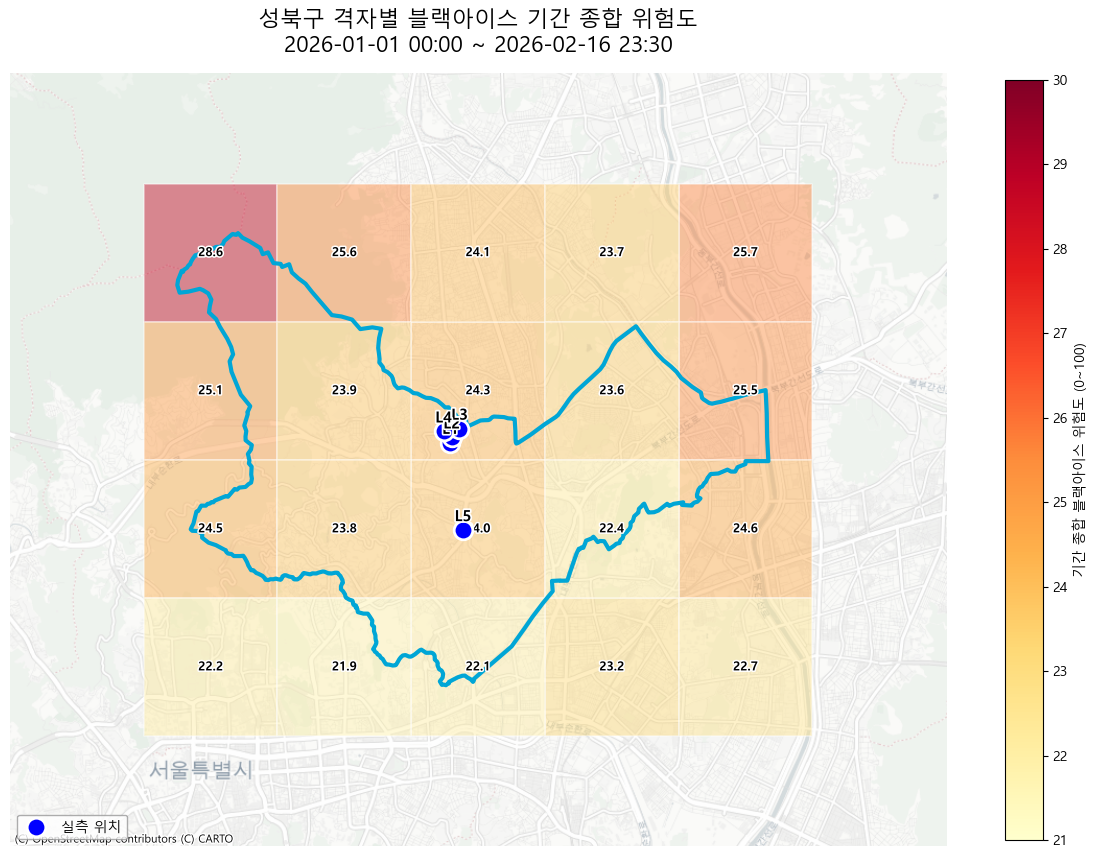

PNG 저장 완료: seongbuk_black_ice_grid_on_map.png
CSV 저장 완료: seongbuk_black_ice_grid_summary.csv


In [57]:
# ============================================================
# 13. 최종 지도 출력
# ============================================================

plot_black_ice_grid_map(
    gdf_web=gdf_web,
    boundary_web=boundary_web,
    df=df,
    grid_summary=grid_summary,
    column_to_plot=COLUMN_TO_PLOT,
    output_png=OUTPUT_PNG,
    output_csv=OUTPUT_CSV,
    grid_alpha=0.45,
    boundary_color="#00A6D6",
    boundary_width=3.0,
    show_cell_score=True,
    color_vmin=21,
    color_vmax=30,
)